<a href="https://colab.research.google.com/github/WVF-1/FULPs-Framework-CA-Application/blob/main/FULPs_CA_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs CA — v5
**Neighbourhood Distress Signalling: Emergent Spatial Coordination via FULP 6**

Author: William V. Fullerton  
Conscientiâ Research Group

---

### What is new in v5

| Component | v4.5 | v5 |
|-----------|------|----|
| Conditions | 3 (base / learn / gate) | 4 (+ signal) |
| FULP implemented | 5 (ARE recursive revision) | 6 (Environmental Interaction) |
| Communication | None | Distress broadcast to 8 neighbours |
| Gating threshold | Fixed GATE_CONF_GATE | Reduced by neighbour distress |
| Primary new metric | — | Moran's I (spatial autocorrelation of gating) |
| Secondary new metric | — | Collective return to equilibrium timestep |

### The Distress Signal
Each cell in the `signal` condition broadcasts a scalar distress value to its 8 neighbours:

    distress_i = max(pos_sim_i, neg_sim_i) × clip(|margin_i|, 0, 1)

- Zero for cells with inactive ARE buffers
- Rises as beliefs form and strengthen
- Spikes when a strongly-held belief is actively contradicted

Neighbours aggregate distress via a 3x3 mean convolution (toroidal).  
A cell with distressed neighbours lowers its own gating threshold:

    effective_GATE_CONF = GATE_CONF_GATE × (1 - SIGNAL_WEIGHT × mean_nbr_distress)

At SIGNAL_WEIGHT=0.25: a cell fully surrounded by max-distress neighbours lowers
GATE_CONF_GATE from 0.80 to 0.60 — exactly the ARE contradiction threshold.
This is biologically motivated: a cell prepares for disruption when neighbours are stressed,
before its own contradictions fully materialise.

### The Central Question
Does local epistemic communication create spatially coordinated adaptive responses?
If yes, gating should cluster spatially (Moran's I > gate condition), and the grid
should return to equilibrium faster collectively (lower CRE timestep).

### FULP 6 — Environmental Interaction
v1–v4.5: cells learn from and react to their environment privately.  
v5: cells communicate their internal epistemic state to neighbours.  
This is the first implementation of FULP 6 in the CA programme — the step from
individual adaptive learners to a communicating adaptive system.

### Paper Notes
- If Moran's I(signal) > Moran's I(gate), spatial coordination is emergent:
  it arises from local communication, not from any global design.
- If CRE(signal) < CRE(gate), collective return to equilibrium is faster —
  the grid as a whole converges faster than its individual parts could predict.
- Both results together constitute the 'breakthrough' claim:
  locally learned epistemic state, communicated to neighbours, produces
  emergent collective order in a deterministic CA system.
- SIGNAL_WEIGHT = 0.25 is a tunable constant. Tune after Cell 11 single-run
  validation if needed, before running Cell 13 multi-run.
  Target: signal gating rate slightly above gate gating rate post-perturbation.

In [1]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [2]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H, GRID_W   = 50, 50
N_TIMESTEPS      = 200
T_PERTURB        = 100
PRE_WIN_START,  PRE_WIN_END  = 50,  100
POST_WIN_START, POST_WIN_END = 150, 200
COLLAPSE_THRESHOLD = 50
NBR_DIM, N_STATES  = 9, 512

# ── VoidStabilizer (unchanged from all prior versions) ────────────────────────
VOID_HIDDEN, EA_TARGET_STD, EA_WEIGHT = 16, 0.3, 0.5
VOID_EPOCHS, VOID_BATCH                = 100, 256
VT_WEIGHT                              = 0.05

# ── ARE (unchanged from v4.5) ─────────────────────────────────────────────────
CONTRA_START, CONTRA_END = 0.20, 0.05
CONF_GATE                = 0.60
BUFFER_DELAY             = 10
EMA_ALPHA                = 0.1
CURIOSITY_WEIGHT         = 2.0

# ── Prediction thresholds (unchanged from v4.5) ───────────────────────────────
BASE_THRESHOLD, CONTRA_THRESHOLD = 0.70, 0.60

# ── Gating (unchanged from v4.5) ──────────────────────────────────────────────
GATE_CONF_GATE     = 0.80
MARGIN_DROP_THRESH = 0.05
MARGIN_EMA_ALPHA   = 0.05
STABLE_MAX_CHANGES = 10

# ── v5 Signalling parameter ───────────────────────────────────────────────────
# SIGNAL_WEIGHT controls how strongly neighbour distress lowers the gating threshold.
# At 0.25: max-distress neighbourhood lowers GATE_CONF_GATE from 0.80 to 0.60.
# Tune after Cell 11 if needed. Target: signal gating rate > gate gating rate post-perturb.
SIGNAL_WEIGHT = 0.25

# ── Spike windows ─────────────────────────────────────────────────────────────
SPIKE_PRE_START, SPIKE_PRE_END     = T_PERTURB - 10, T_PERTURB
SPIKE_POST_START, SPIKE_POST_END   = T_PERTURB + 1,  T_PERTURB + 11

# ── Multi-run ─────────────────────────────────────────────────────────────────
N_RUNS, BATCH_SIZE = 50, 5
BASE_SEED          = 42
OUT_DIR            = '/content'
REP_DIM            = VOID_HIDDEN

print('Configuration ready.')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  T_PERTURB: {T_PERTURB}')
print(f'  SIGNAL_WEIGHT={SIGNAL_WEIGHT}  (tune after Cell 11 if needed)')
print(f'  GATE_CONF_GATE={GATE_CONF_GATE}  CONF_GATE={CONF_GATE}')
print(f'  At max distress: effective threshold = {GATE_CONF_GATE*(1-SIGNAL_WEIGHT):.3f}')
print(f'  Multi-run: {N_RUNS} runs (seeds {BASE_SEED}-{BASE_SEED+N_RUNS-1})')

Configuration ready.
  Grid: 50x50  |  Timesteps: 200  |  T_PERTURB: 100
  SIGNAL_WEIGHT=0.25  (tune after Cell 11 if needed)
  GATE_CONF_GATE=0.8  CONF_GATE=0.6
  At max distress: effective threshold = 0.600
  Multi-run: 50 runs (seeds 42-91)


In [3]:
# ── Cell 3: GoL (unchanged from v3–v4.5) ─────────────────────────────────────
def tick(grid, perturbed=False):
    H, W = grid.shape
    nc = np.zeros((H, W), dtype=np.int8)
    for di in [-1,0,1]:
        for dj in [-1,0,1]:
            if di==0 and dj==0: continue
            nc += np.roll(np.roll(grid, di, 0), dj, 1)
    nxt = np.zeros((H, W), dtype=np.int8)
    a = grid==1
    if perturbed: nxt[a & ((nc==2)|(nc==3)|(nc==4))] = 1
    else:         nxt[a & ((nc==2)|(nc==3))]         = 1
    nxt[~a & (nc==3)] = 1
    return nxt

def population(g): return int(g.sum())

_t1=np.zeros((10,10),dtype=np.int8); _t1[1,2]=_t1[2,3]=_t1[3,1]=_t1[3,2]=_t1[3,3]=1
assert population(tick(_t1))==5
_t2=np.zeros((5,5),dtype=np.int8); _t2[2,2]=_t2[1,2]=_t2[3,2]=_t2[2,1]=_t2[2,3]=1
assert tick(_t2)[2,2]==0 and tick(_t2,True)[2,2]==1
print('GoL defined. Sanity checks: PASS')

GoL defined. Sanity checks: PASS


In [4]:
# ── Cell 4: IDF (unchanged) ───────────────────────────────────────────────────
class InnerDepthField:
    def __init__(self, seq_len=NBR_DIM): self.seq_len=seq_len
    def _cm(self, rho):
        idx=np.arange(self.seq_len)
        return rho**np.abs(idx[:,None]-idx[None,:])+np.eye(self.seq_len)*1e-6
    def sample(self, n):
        X=np.zeros((n,self.seq_len))
        for i in range(n):
            mu=np.random.normal(0,0.02); sig=np.random.uniform(0.05,0.30); rho=np.random.uniform(-0.2,0.2)
            try:    L=cholesky(self._cm(rho),lower=True); X[i]=mu+sig*(L@np.random.normal(0,1,self.seq_len))
            except: X[i]=np.random.normal(mu,sig,self.seq_len)
        return X
    def sample_tensor(self,n): return torch.FloatTensor(self.sample(n).astype(np.float32))

IDF=InnerDepthField(); print('IDF defined.')

IDF defined.


In [5]:
# ── Cell 5: VoidStabilizer (unchanged) ───────────────────────────────────────
class VoidStabilizer(nn.Module):
    def __init__(self,seq_len=NBR_DIM,hidden_dim=VOID_HIDDEN,ea_target_std=EA_TARGET_STD,ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std=ea_target_std; self.ea_weight=ea_weight
        self.encoder=nn.Sequential(nn.Linear(seq_len,hidden_dim),nn.Tanh())
        self.decoder=nn.Linear(hidden_dim,seq_len)
    def forward(self,x): z=self.encoder(x); return self.decoder(z),z
    def encode(self,x): return self.encoder(x)
    def dsc(self,x): x_hat,_=self.forward(x); return torch.mean((x-x_hat)**2,dim=1)
    def void_tether(self,idf,n=64):
        with torch.no_grad(): return float(self.dsc(idf.sample_tensor(n)).mean().item())
    def training_loss(self,x):
        x_hat,z=self.forward(x); r=nn.MSELoss()(x_hat,x); ea=(z.std()-self.ea_target_std)**2
        return r+self.ea_weight*ea,r.item(),ea.item()

def train_void_stabilizer(vm,idf,n_epochs=VOID_EPOCHS,batch_size=VOID_BATCH,lr=1e-3,verbose=True):
    opt=torch.optim.Adam(vm.parameters(),lr=lr); hist={'total':[],'recon':[],'ea':[]}
    for ep in range(n_epochs):
        xv=idf.sample_tensor(batch_size); tot,r,ea=vm.training_loss(xv)
        opt.zero_grad(); tot.backward(); opt.step()
        hist['total'].append(tot.item()); hist['recon'].append(r); hist['ea'].append(ea)
        if verbose and ep%25==0: print(f'    [Void {ep:3d}]  total={tot.item():.4f}  recon={r:.4f}  EA={ea:.4f}')
    return hist

print('VoidStabilizer defined (9->16->9).')

VoidStabilizer defined (9->16->9).


STAGE 0: Void Stabilization
    [Void   0]  total=0.0740  recon=0.0705  EA=0.0070
    [Void  25]  total=0.0451  recon=0.0419  EA=0.0064
    [Void  50]  total=0.0319  recon=0.0292  EA=0.0055
    [Void  75]  total=0.0266  recon=0.0248  EA=0.0037

Frozen. recon=0.0194  EA=0.0023


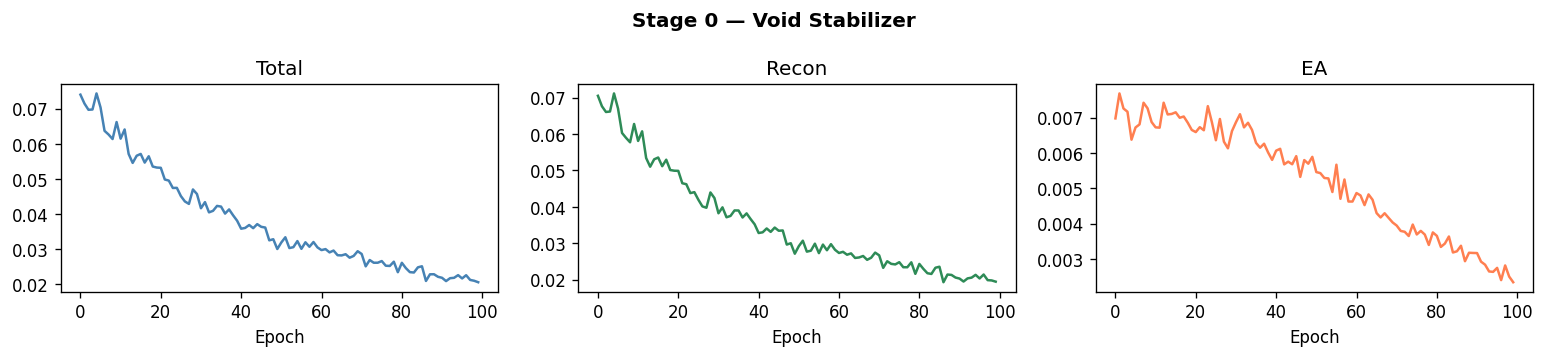

Saved: fulps_ca_v5_void_training.png


In [6]:
# ── Cell 6: Stage 0 — Void Stabilization ─────────────────────────────────────
print('='*60); print('STAGE 0: Void Stabilization'); print('='*60)
torch.manual_seed(BASE_SEED); np.random.seed(BASE_SEED)
void_model=VoidStabilizer()
void_hist=train_void_stabilizer(void_model,IDF,verbose=True)
for p in void_model.parameters(): p.requires_grad=False
void_model.eval()
print(f'\nFrozen. recon={void_hist["recon"][-1]:.4f}  EA={void_hist["ea"][-1]:.4f}')
fig,axes=plt.subplots(1,3,figsize=(13,3)); fig.suptitle('Stage 0 — Void Stabilizer',fontweight='bold')
for ax,k,c,l in zip(axes,['total','recon','ea'],['steelblue','seagreen','coral'],['Total','Recon','EA']):
    ax.plot(void_hist[k],color=c); ax.set_title(l); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulps_ca_v5_void_training.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Saved: fulps_ca_v5_void_training.png')

DSC THRESHOLD CALIBRATION
  IDF: mean=0.0199  CA: mean=0.1291  Threshold: 0.0526
  Separation: OK


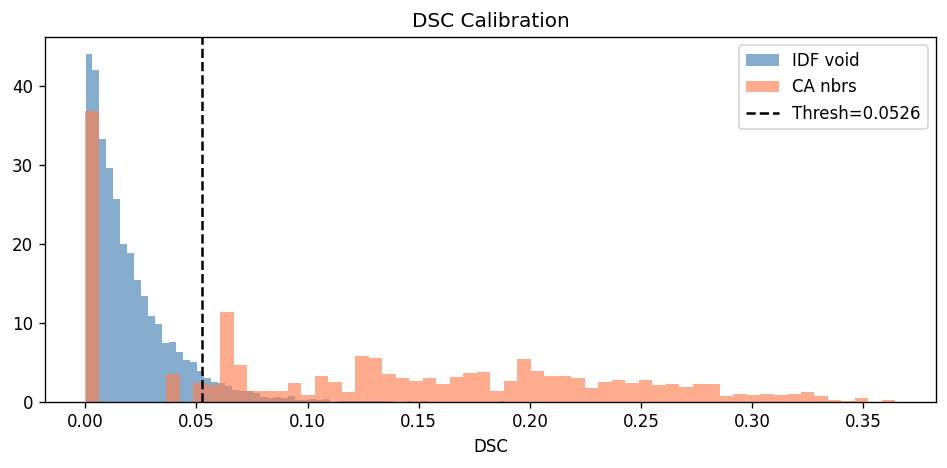

Saved: fulps_ca_v5_dsc_calibration.png


In [7]:
# ── Cell 7: DSC Threshold Calibration ────────────────────────────────────────
print('='*60); print('DSC THRESHOLD CALIBRATION'); print('='*60)
np.random.seed(0); cg=np.random.randint(0,2,size=(GRID_H,GRID_W),dtype=np.int8); dsc_all=[]
_sc=[(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]
for _ in range(5):
    ch=np.zeros((GRID_H,GRID_W,9),dtype=np.float32)
    for k,(di,dj) in enumerate(_sc): ch[:,:,k]=np.roll(np.roll(cg,-di,0),-dj,1).astype(np.float32)
    with torch.no_grad(): dsc_all.append(void_model.dsc(torch.FloatTensor(ch.reshape(-1,NBR_DIM))).numpy())
    cg=tick(cg)
dsc_all=np.concatenate(dsc_all)
with torch.no_grad(): idf_ref=void_model.dsc(IDF.sample_tensor(5000)).numpy()
DSC_THRESHOLD=float(np.percentile(dsc_all,25))
print(f'  IDF: mean={idf_ref.mean():.4f}  CA: mean={dsc_all.mean():.4f}  Threshold: {DSC_THRESHOLD:.4f}')
print(f'  Separation: {"OK" if idf_ref.mean()<dsc_all.mean() else "WARNING"}')
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(idf_ref,bins=60,alpha=0.65,color='steelblue',label='IDF void',density=True)
ax.hist(dsc_all, bins=60,alpha=0.65,color='coral',label='CA nbrs',density=True)
ax.axvline(DSC_THRESHOLD,color='black',linestyle='--',lw=1.5,label=f'Thresh={DSC_THRESHOLD:.4f}')
ax.set_xlabel('DSC'); ax.legend(); ax.set_title('DSC Calibration')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulps_ca_v5_dsc_calibration.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Saved: fulps_ca_v5_dsc_calibration.png')

In [8]:
# ── Cell 8: Grid and Spatial Utilities ───────────────────────────────────────
def _build_truth(perturbed):
    t=np.zeros(N_STATES,dtype=np.int8)
    for s in range(N_STATES):
        bits=np.array([(s>>k)&1 for k in range(9)],dtype=np.int8)
        own=int(bits[4]); n=int(bits.sum())-own
        ss=[2,3,4] if perturbed else [2,3]
        t[s]=1 if (own==1 and n in ss) or (own==0 and n==3) else 0
    return t

GOL_TRUTH_ORIG=_build_truth(False); GOL_TRUTH_PERT=_build_truth(True)
AFFECTED_MASK=(GOL_TRUTH_ORIG!=GOL_TRUTH_PERT)
_II=np.arange(GRID_H)[:,None]*np.ones(GRID_W,dtype=int)[None,:]
_JJ=np.ones(GRID_H,dtype=int)[:,None]*np.arange(GRID_W)[None,:]
_POWERS=(2**np.arange(9)).astype(np.int32)
_SHIFTS=[(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]

def encode_neighbourhoods(grid):
    ch=np.zeros((GRID_H,GRID_W,9),dtype=np.float32)
    for k,(di,dj) in enumerate(_SHIFTS): ch[:,:,k]=np.roll(np.roll(grid,-di,0),-dj,1).astype(np.float32)
    return (ch.astype(np.int32)*_POWERS[None,None,:]).sum(axis=-1),ch

def predict_from_table(table,nbr_indices,contradiction_mask=None):
    c=table[_II,_JJ,nbr_indices]; p=c[...,1]/np.maximum(c.sum(axis=-1),1)
    thresh=np.full((GRID_H,GRID_W),BASE_THRESHOLD,dtype=np.float32)
    if contradiction_mask is not None: thresh=np.where(contradiction_mask,CONTRA_THRESHOLD,BASE_THRESHOLD)
    return (p>thresh).astype(np.int8)

def table_accuracy_grid(table,truth):
    p=table[...,1]/np.maximum(table.sum(axis=-1),1)
    return ((p>BASE_THRESHOLD).astype(np.int8)==truth[None,None,:]).mean(axis=-1).astype(np.float32)

def table_coverage_grid(table): return (table.max(axis=-1)>1.0).mean(axis=-1).astype(np.float32)

def per_state_accuracy_grid(table,truth):
    obs=(table.max(axis=-1)>1.0); p=table[...,1]/np.maximum(table.sum(axis=-1),1)
    corr=((p>BASE_THRESHOLD).astype(np.int8)==truth[None,None,:])&obs
    n=obs.sum(axis=-1).astype(np.float32)
    return np.where(n>0,corr.sum(axis=-1).astype(np.float32)/np.maximum(n,1),np.nan).astype(np.float32)

def affected_state_accuracy(table,nbr_indices,truth):
    ia=AFFECTED_MASK[nbr_indices]; n=int(ia.sum())
    if n==0: return np.nan,0
    c=table[_II,_JJ,nbr_indices]; p=c[...,1]/np.maximum(c.sum(axis=-1),1)
    return float(((p>BASE_THRESHOLD).astype(np.int8)[ia]==truth[nbr_indices][ia]).mean()),n

def detect_stable_cells(sh,mc=STABLE_MAX_CHANGES):
    return np.sum(np.abs(np.diff(sh.astype(np.int16),axis=0)),axis=0)<=mc

def compute_cv(pl,s,e):
    a=np.array(pl[s:e],dtype=np.float64)
    return float(a.std()/a.mean()) if a.mean()>1e-6 else np.nan

def compute_morans_i(binary_grid):
    """
    Moran's I spatial autocorrelation on a binary [H,W] grid (toroidal).
    Returns values in [-1, 1]:
      +1 = perfectly clustered  (gating propagates spatially)
       0 = random spatial pattern
      -1 = perfectly dispersed
    If no cells are active or all cells are active, returns 0.0.
    """
    x = binary_grid.astype(np.float64)
    n = x.size; mean_x = x.mean()
    if mean_x < 1e-9 or mean_x > 1-1e-9: return 0.0
    z = x - mean_x
    # Spatial lag: mean of 8 toroidal neighbours
    lag = np.zeros_like(z)
    for di in [-1,0,1]:
        for dj in [-1,0,1]:
            if di==0 and dj==0: continue
            lag += np.roll(np.roll(z, di, 0), dj, 1)
    lag /= 8.0
    num   = n * np.sum(z * lag)
    denom = 8.0 * np.sum(z**2)   # W = n*8 for toroidal 8-connectivity
    return float(num/denom) if abs(denom)>1e-9 else 0.0

def compute_nbr_mean_distress(distress_grid):
    """
    Per-cell mean distress of 8 toroidal neighbours (excluding self).
    Used by signal condition to lower effective gating threshold.
    """
    nbr_sum = np.zeros((GRID_H,GRID_W),dtype=np.float32)
    for di in [-1,0,1]:
        for dj in [-1,0,1]:
            if di==0 and dj==0: continue
            nbr_sum += np.roll(np.roll(distress_grid, di, 0), dj, 1)
    return nbr_sum / 8.0

print(f'Grid + spatial utilities defined.')
print(f'  compute_morans_i, compute_nbr_mean_distress  (v5 new)')
print(f'  Affected: {AFFECTED_MASK.sum()}/512 states')

Grid + spatial utilities defined.
  compute_morans_i, compute_nbr_mean_distress  (v5 new)
  Affected: 70/512 states


In [9]:
# ── Cell 9: FULPs State — Tables, ARE, Gating, Signalling ────────────────────

def init_tables():    return np.ones((GRID_H,GRID_W,N_STATES,2),dtype=np.float32)
def init_are_state(): return {'pos_rep':np.zeros((GRID_H,GRID_W,REP_DIM),dtype=np.float32),
                               'neg_rep':np.zeros((GRID_H,GRID_W,REP_DIM),dtype=np.float32),
                               'pos_active':np.zeros((GRID_H,GRID_W),dtype=bool),
                               'neg_active':np.zeros((GRID_H,GRID_W),dtype=bool),
                               'margin_ema':np.zeros((GRID_H,GRID_W),dtype=np.float32)}
def init_conv_state(): return {'f_timestep':np.full((GRID_H,GRID_W),float(N_TIMESTEPS),dtype=np.float32),
                                'f_locked':np.zeros((GRID_H,GRID_W),dtype=bool),
                                'visit_counts':np.zeros((GRID_H,GRID_W,N_STATES),dtype=np.int32)}
def init_rec_state():  return {'recovery_t':np.full((GRID_H,GRID_W),float(N_TIMESTEPS),dtype=np.float32),
                                'rec_locked':np.zeros((GRID_H,GRID_W),dtype=bool),
                                'has_observed':np.zeros((GRID_H,GRID_W),dtype=bool)}

def compute_are_margin(reps_flat, are_state, threshold):
    rep=reps_flat.reshape(GRID_H,GRID_W,REP_DIM)
    def cs(a,b):
        d=np.sum(a*b,axis=-1)
        return d/np.where(np.linalg.norm(a,axis=-1)*np.linalg.norm(b,axis=-1)>1e-8,
                          np.linalg.norm(a,axis=-1)*np.linalg.norm(b,axis=-1),1e-8)
    ps=np.where(are_state['pos_active'],cs(rep,are_state['pos_rep']),0.0)
    ns=np.where(are_state['neg_active'],cs(rep,are_state['neg_rep']),0.0)
    m=ps-ns; both=are_state['pos_active']&are_state['neg_active']
    contra=(np.abs(m)<threshold)&(np.maximum(ps,ns)>CONF_GATE)&both
    return m,contra,ps,ns

def update_are_buffers(are_state,reps_flat,outcomes):
    rep=reps_flat.reshape(GRID_H,GRID_W,REP_DIM)
    for mask,key in [(outcomes==1,'pos'),(outcomes==0,'neg')]:
        if mask.any():
            are_state[f'{key}_rep'][mask]=(1-EMA_ALPHA)*are_state[f'{key}_rep'][mask]+EMA_ALPHA*rep[mask]
            are_state[f'{key}_active'][mask]=True

def update_table_single(table,ni,outcomes,cw):
    table[_II,_JJ,ni,outcomes.astype(int)]+=cw

def update_convergence_single(cs,t,table,ni,outcomes,ac):
    cs['visit_counts'][_II,_JJ,ni]+=1
    v=cs['visit_counts'][_II,_JJ,ni]; o2=(v>=2)
    c=table[_II,_JJ,ni]; p=c[...,1]/np.maximum(c.sum(axis=-1),1)
    th=np.where(ac,CONTRA_THRESHOLD,BASE_THRESHOLD)
    corr=((p>th).astype(np.int8)==outcomes); conf=np.where(outcomes==1,p>th,p<(1-th))
    newly=corr&conf&o2&~cs['f_locked']; cs['f_timestep'][newly]=t; cs['f_locked'][newly]=True

def update_recovery_single(rs,t,table,ni,ac):
    ia=AFFECTED_MASK[ni]
    if not ia.any(): return
    rs['has_observed'][ia]=True
    c=table[_II,_JJ,ni]; p=c[...,1]/np.maximum(c.sum(axis=-1),1)
    th=np.where(ac,CONTRA_THRESHOLD,BASE_THRESHOLD)
    newly=ia&(p>th)&~rs['rec_locked']; rs['recovery_t'][newly]=t; rs['rec_locked'][newly]=True

def compute_gating_mask(ac_gate, pos_sim, neg_sim, are_state, nbr_distress=None):
    """
    v4.5 gating: contradiction AND strong belief AND margin deteriorating.
    v5 extension: if nbr_distress provided (signal condition), lower effective
    GATE_CONF_GATE proportionally to mean neighbour distress.

    effective_conf = GATE_CONF_GATE × (1 - SIGNAL_WEIGHT × nbr_distress)
    """
    max_sim = np.maximum(pos_sim, neg_sim)
    if nbr_distress is not None:
        # Signal condition: neighbours lower the gating threshold
        nbr_distress_clipped = np.clip(nbr_distress, 0.0, 1.0)
        effective_conf = GATE_CONF_GATE * (1.0 - SIGNAL_WEIGHT * nbr_distress_clipped)
        strong_belief  = max_sim > effective_conf
    else:
        strong_belief = max_sim > GATE_CONF_GATE
    # Margin deterioration check (from v4.5)
    margin_drop = (are_state['margin_ema'] - np.abs(ac_gate.astype(np.float32))) > MARGIN_DROP_THRESH
    return ac_gate & strong_belief

def compute_distress(pos_sim, neg_sim, margin):
    """
    Distress scalar per cell: high when belief is strong AND currently violated.
    distress = max(pos_sim, neg_sim) × clip(|margin|, 0, 1)
    Range [0, 1]. Zero for cells with inactive buffers.
    """
    return np.maximum(pos_sim, neg_sim) * np.clip(np.abs(margin), 0.0, 1.0)

def cre_timestep(contra_history, pre_mean, post_start, tolerance=0.05):
    """
    Collective Return to Equilibrium: first t >= post_start where mean
    contradiction rate falls back to within tolerance of pre-perturbation mean
    and stays there for 5 consecutive timesteps.
    Returns N_TIMESTEPS if never achieved.
    """
    if np.isnan(pre_mean): return float(N_TIMESTEPS)
    threshold = pre_mean + tolerance
    for t in range(post_start, N_TIMESTEPS - 4):
        if all(contra_history[t+k] <= threshold for k in range(5)):
            return float(t)
    return float(N_TIMESTEPS)

def om(arr, mask):
    if not mask.any(): return np.nan
    v=arr[mask]; v=v[~np.isnan(v)]; return float(v.mean()) if len(v)>0 else np.nan

print('FULPs state utilities defined.')
print('  v5 new: compute_distress, compute_nbr_mean_distress, cre_timestep')
print('  compute_gating_mask: signal condition lowers threshold by nbr_distress')

FULPs state utilities defined.
  v5 new: compute_distress, compute_nbr_mean_distress, cre_timestep
  compute_gating_mask: signal condition lowers threshold by nbr_distress


In [10]:
# ── Cell 10: Simulation Engine ────────────────────────────────────────────────
def run_simulation(seed, void_model, idf, is_single_run=False, verbose=False):
    """
    v5: FOUR simultaneous conditions per seed.

    base   : standard GoL + uniform table
    learn  : standard GoL + FULPs table+ARE  (same grid as base)
    gate   : selective-gated GoL + FULPs (v4.5 unchanged)
    signal : selective-gated GoL + FULPs + distress broadcast (v5 NEW)

    Distress signal (FULP 6):
      Each signal cell broadcasts distress = max(pos_sim, neg_sim) × |margin|
      Neighbours aggregate via 3×3 mean convolution (toroidal).
      High mean neighbour distress lowers the local gating threshold:
        effective_GATE_CONF = GATE_CONF_GATE × (1 - SIGNAL_WEIGHT × nbr_distress)
      ARE updates remain SEPARATE from gating (FULPs principle).
    """
    np.random.seed(seed); torch.manual_seed(seed)

    grid_std  = np.random.randint(0,2,size=(GRID_H,GRID_W),dtype=np.int8)
    grid_gate = grid_std.copy()
    grid_sig  = grid_std.copy()

    base_table=init_tables(); learn_table=init_tables()
    gate_table=init_tables(); sig_table  =init_tables()
    are_learn=init_are_state(); are_gate=init_are_state(); are_sig=init_are_state()
    conv_base=init_conv_state(); conv_learn=init_conv_state()
    conv_gate=init_conv_state(); conv_sig =init_conv_state()
    rec_base=init_rec_state(); rec_learn=init_rec_state()
    rec_gate=init_rec_state(); rec_sig  =init_rec_state()

    sh_std=np.zeros((N_TIMESTEPS,GRID_H,GRID_W),dtype=np.int8)
    sh_gate=np.zeros((N_TIMESTEPS,GRID_H,GRID_W),dtype=np.int8)
    sh_sig=np.zeros((N_TIMESTEPS,GRID_H,GRID_W),dtype=np.int8)

    pop_std=[]; pop_gate=[]; pop_sig=[]
    contra_l_h=[]; contra_gate_h=[]; contra_sig_h=[]
    gate_h=[]; sig_h=[]; morans_gate_h=[]; morans_sig_h=[]
    distress_mean_h=[]

    hist=None
    if is_single_run:
        hist={
            'pop_std':[],'pop_gate':[],'pop_sig':[],'pop_diff_gate':[],'pop_diff_sig':[],
            'contra_l':[],'gate_rate':[],'sig_rate':[],'distress_mean':[],
            'morans_gate':[],'morans_sig':[],'vt_signal':[],
            'tacc_base':[],'tacc_learn':[],'tacc_gate':[],'tacc_sig':[],
            'rec_base':[],'rec_learn':[],'rec_gate':[],'rec_sig':[],
            'aff_base':[],'aff_gate':[],'aff_sig':[],
        }

    for t in range(N_TIMESTEPS):
        sh_std[t]=grid_std.copy(); sh_gate[t]=grid_gate.copy(); sh_sig[t]=grid_sig.copy()
        is_pert=(t>=T_PERTURB); ct=GOL_TRUTH_PERT if is_pert else GOL_TRUTH_ORIG

        # ── Standard grid (base + learn) ──────────────────────────────────
        nbr_std,nbr_std_f=encode_neighbourhoods(grid_std)
        nt_std=torch.FloatTensor(nbr_std_f.reshape(-1,NBR_DIM))
        with torch.no_grad():
            dsc_std=void_model.dsc(nt_std).numpy().reshape(GRID_H,GRID_W)
            reps_std=void_model.encode(nt_std).numpy()
        next_std=tick(grid_std,perturbed=is_pert); out_std=next_std.astype(np.int8)
        prog=t/max(N_TIMESTEPS-1,1)
        thresh=CONTRA_START+(CONTRA_END-CONTRA_START)*prog

        ml,cl,_,_=compute_are_margin(reps_std,are_learn,thresh)
        acl=cl&(dsc_std>DSC_THRESHOLD)
        cwl=np.ones((GRID_H,GRID_W),dtype=np.float32); cwl[acl]=CURIOSITY_WEIGHT
        contra_l_h.append(float(cl.mean()))
        nc=np.zeros((GRID_H,GRID_W),dtype=bool)
        update_table_single(base_table,nbr_std,out_std,np.ones((GRID_H,GRID_W),dtype=np.float32))
        update_table_single(learn_table,nbr_std,out_std,cwl)
        if t>=BUFFER_DELAY: update_are_buffers(are_learn,reps_std,out_std)
        update_convergence_single(conv_base,t,base_table,nbr_std,out_std,nc)
        update_convergence_single(conv_learn,t,learn_table,nbr_std,out_std,acl)
        if is_pert:
            update_recovery_single(rec_base,t,base_table,nbr_std,nc)
            update_recovery_single(rec_learn,t,learn_table,nbr_std,acl)

        # ── Gate grid (v4.5 — unchanged) ──────────────────────────────────
        nbr_gate,nbr_gate_f=encode_neighbourhoods(grid_gate)
        nt_gate=torch.FloatTensor(nbr_gate_f.reshape(-1,NBR_DIM))
        with torch.no_grad():
            dsc_g=void_model.dsc(nt_gate).numpy().reshape(GRID_H,GRID_W)
            reps_g=void_model.encode(nt_gate).numpy()
        mg,cg,psg,nsg=compute_are_margin(reps_g,are_gate,thresh)
        acg=cg&(dsc_g>DSC_THRESHOLD)
        gating_mask=compute_gating_mask(acg,psg,nsg,are_gate,nbr_distress=None)
        gate_h.append(float(gating_mask.mean()))
        contra_gate_h.append(float(cg.mean()))
        cwg=np.ones((GRID_H,GRID_W),dtype=np.float32); cwg[acg]=CURIOSITY_WEIGHT
        next_gate=tick(grid_gate,perturbed=is_pert).copy()
        next_gate[gating_mask]=grid_gate[gating_mask]; out_gate=next_gate.astype(np.int8)
        update_table_single(gate_table,nbr_gate,out_gate,cwg)
        if t>=BUFFER_DELAY: update_are_buffers(are_gate,reps_g,out_gate)
        update_convergence_single(conv_gate,t,gate_table,nbr_gate,out_gate,acg)
        if is_pert: update_recovery_single(rec_gate,t,gate_table,nbr_gate,acg)
        morans_gate_h.append(compute_morans_i(gating_mask))

        # ── Signal grid (v5 NEW — distress broadcast) ──────────────────────
        nbr_sig,nbr_sig_f=encode_neighbourhoods(grid_sig)
        nt_sig=torch.FloatTensor(nbr_sig_f.reshape(-1,NBR_DIM))
        with torch.no_grad():
            dsc_s=void_model.dsc(nt_sig).numpy().reshape(GRID_H,GRID_W)
            reps_s=void_model.encode(nt_sig).numpy()
        ms,cs_,pss,nss=compute_are_margin(reps_s,are_sig,thresh)
        acs=cs_&(dsc_s>DSC_THRESHOLD)
        contra_sig_h.append(float(cs_.mean()))
        # Compute distress and broadcast to neighbours
        distress=compute_distress(pss,nss,ms)          # [H,W] per-cell distress
        nbr_dist=compute_nbr_mean_distress(distress)   # [H,W] mean neighbour distress
        distress_mean_h.append(float(distress.mean()))
        # Gating with signal: effective threshold lowered by neighbour distress
        sig_mask=compute_gating_mask(acs,pss,nss,are_sig,nbr_distress=nbr_dist)
        sig_h.append(float(sig_mask.mean()))
        cws=np.ones((GRID_H,GRID_W),dtype=np.float32); cws[acs]=CURIOSITY_WEIGHT
        next_sig=tick(grid_sig,perturbed=is_pert).copy()
        next_sig[sig_mask]=grid_sig[sig_mask]; out_sig=next_sig.astype(np.int8)
        # ARE updates separate from gating — cells learn while deferring action
        update_table_single(sig_table,nbr_sig,out_sig,cws)
        if t>=BUFFER_DELAY: update_are_buffers(are_sig,reps_s,out_sig)
        update_convergence_single(conv_sig,t,sig_table,nbr_sig,out_sig,acs)
        if is_pert: update_recovery_single(rec_sig,t,sig_table,nbr_sig,acs)
        morans_sig_h.append(compute_morans_i(sig_mask))

        pop_std.append(population(grid_std))
        pop_gate.append(population(grid_gate))
        pop_sig.append(population(grid_sig))

        if is_single_run:
            rf_b=rec_base['rec_locked'].sum()/max(rec_base['has_observed'].sum(),1)
            rf_l=rec_learn['rec_locked'].sum()/max(rec_learn['has_observed'].sum(),1)
            rf_g=rec_gate['rec_locked'].sum()/max(rec_gate['has_observed'].sum(),1)
            rf_s=rec_sig['rec_locked'].sum()/max(rec_sig['has_observed'].sum(),1)
            fa_b,_=affected_state_accuracy(base_table,nbr_std,ct)
            fa_g,_=affected_state_accuracy(gate_table,nbr_gate,ct)
            fa_s,_=affected_state_accuracy(sig_table,nbr_sig,ct)
            hist['pop_std'].append(population(grid_std))
            hist['pop_gate'].append(population(grid_gate))
            hist['pop_sig'].append(population(grid_sig))
            hist['pop_diff_gate'].append(abs(population(grid_gate)-population(grid_std)))
            hist['pop_diff_sig'].append(abs(population(grid_sig)-population(grid_std)))
            hist['contra_l'].append(float(cl.mean()))
            hist['gate_rate'].append(float(gating_mask.mean()))
            hist['sig_rate'].append(float(sig_mask.mean()))
            hist['distress_mean'].append(float(distress.mean()))
            hist['morans_gate'].append(compute_morans_i(gating_mask))
            hist['morans_sig'].append(compute_morans_i(sig_mask))
            hist['vt_signal'].append(void_model.void_tether(idf,n=64))
            hist['tacc_base'].append(float(table_accuracy_grid(base_table,ct).mean()))
            hist['tacc_learn'].append(float(table_accuracy_grid(learn_table,ct).mean()))
            hist['tacc_gate'].append(float(table_accuracy_grid(gate_table,ct).mean()))
            hist['tacc_sig'].append(float(table_accuracy_grid(sig_table,ct).mean()))
            hist['rec_base'].append(float(rf_b)); hist['rec_learn'].append(float(rf_l))
            hist['rec_gate'].append(float(rf_g)); hist['rec_sig'].append(float(rf_s))
            hist['aff_base'].append(fa_b); hist['aff_gate'].append(fa_g); hist['aff_sig'].append(fa_s)
            if verbose and t%10==0:
                m=' <<PERTURB' if t==T_PERTURB else ''
                print(f'  [t={t:3d}] pop_std={population(grid_std):4d} '
                      f'pop_gate={population(grid_gate):4d} pop_sig={population(grid_sig):4d}  '
                      f'gate={gating_mask.mean():.3f} sig={sig_mask.mean():.3f}  '
                      f'dist={distress.mean():.3f}  Mi_g={compute_morans_i(gating_mask):.3f}  '
                      f'Mi_s={compute_morans_i(sig_mask):.3f}{m}')

        grid_std=next_std; grid_gate=next_gate; grid_sig=next_sig

    # ── Post-simulation ────────────────────────────────────────────────────
    ss=detect_stable_cells(sh_std); sg=detect_stable_cells(sh_gate); si=detect_stable_cells(sh_sig)
    pre_contra_mean=float(np.mean(contra_l_h[SPIKE_PRE_START:SPIKE_PRE_END]))

    results={
        # Accuracy
        'base_final_tacc'  :float(table_accuracy_grid(base_table,GOL_TRUTH_PERT).mean()),
        'learn_final_tacc' :float(table_accuracy_grid(learn_table,GOL_TRUTH_PERT).mean()),
        'gate_final_tacc'  :float(table_accuracy_grid(gate_table,GOL_TRUTH_PERT).mean()),
        'sig_final_tacc'   :float(table_accuracy_grid(sig_table,GOL_TRUTH_PERT).mean()),
        'gate_final_perstate':float(np.nanmean(per_state_accuracy_grid(gate_table,GOL_TRUTH_PERT))),
        'sig_final_perstate' :float(np.nanmean(per_state_accuracy_grid(sig_table,GOL_TRUTH_PERT))),
        # Stability (CV)
        'cv_base_pre'  :compute_cv(pop_std, PRE_WIN_START,  PRE_WIN_END),
        'cv_gate_pre'  :compute_cv(pop_gate,PRE_WIN_START,  PRE_WIN_END),
        'cv_sig_pre'   :compute_cv(pop_sig, PRE_WIN_START,  PRE_WIN_END),
        'cv_base_post' :compute_cv(pop_std, POST_WIN_START, POST_WIN_END),
        'cv_gate_post' :compute_cv(pop_gate,POST_WIN_START, POST_WIN_END),
        'cv_sig_post'  :compute_cv(pop_sig, POST_WIN_START, POST_WIN_END),
        # Recovery
        'base_recovery_t'  :om(rec_base['recovery_t'],rec_base['has_observed']),
        'gate_recovery_t'  :om(rec_gate['recovery_t'],rec_gate['has_observed']),
        'sig_recovery_t'   :om(rec_sig['recovery_t'], rec_sig['has_observed']),
        'base_recovery_frac':float(rec_base['rec_locked'].sum())/max(float(rec_base['has_observed'].sum()),1),
        'gate_recovery_frac':float(rec_gate['rec_locked'].sum())/max(float(rec_gate['has_observed'].sum()),1),
        'sig_recovery_frac' :float(rec_sig['rec_locked'].sum())/max(float(rec_sig['has_observed'].sum()),1),
        # Moran's I (spatial autocorrelation — PRIMARY v5 metric)
        'mi_gate_pre'  :float(np.mean(morans_gate_h[PRE_WIN_START:PRE_WIN_END])),
        'mi_sig_pre'   :float(np.mean(morans_sig_h[PRE_WIN_START:PRE_WIN_END])),
        'mi_gate_post' :float(np.mean(morans_gate_h[POST_WIN_START:POST_WIN_END])),
        'mi_sig_post'  :float(np.mean(morans_sig_h[POST_WIN_START:POST_WIN_END])),
        # Collective Return to Equilibrium
        'cre_base'     :cre_timestep(contra_l_h,   pre_contra_mean, T_PERTURB+1),
        'cre_gate'     :cre_timestep(contra_gate_h, pre_contra_mean, T_PERTURB+1),
        'cre_sig'      :cre_timestep(contra_sig_h,  pre_contra_mean, T_PERTURB+1),
        # Gating
        'gate_mean_overall':float(np.mean(gate_h)),
        'sig_mean_overall' :float(np.mean(sig_h)),
        'distress_mean_overall':float(np.mean(distress_mean_h)),
        'contra_spike':float(np.mean(contra_l_h[SPIKE_POST_START:SPIKE_POST_END]))-pre_contra_mean,
        'gate_spike'  :float(np.mean(gate_h[SPIKE_POST_START:SPIKE_POST_END]))-
                       float(np.mean(gate_h[SPIKE_PRE_START:SPIKE_PRE_END])),
        'sig_spike'   :float(np.mean(sig_h[SPIKE_POST_START:SPIKE_POST_END]))-
                       float(np.mean(sig_h[SPIKE_PRE_START:SPIKE_PRE_END])),
        # Divergence
        'grid_div_gate':float(np.mean(grid_std!=grid_gate)),
        'grid_div_sig' :float(np.mean(grid_std!=grid_sig)),
        # Stable fraction
        'stable_std' :float(ss.mean()),
        'stable_gate':float(sg.mean()),
        'stable_sig' :float(si.mean()),
    }

    fs=None
    if is_single_run:
        fs={'grid_std':grid_std,'grid_gate':grid_gate,'grid_sig':grid_sig,
            'gating_mask_final':gating_mask,'sig_mask_final':sig_mask,
            'distress_final':distress,'pop_std':pop_std,'pop_gate':pop_gate,'pop_sig':pop_sig}
    return hist,results,fs

print('Simulation engine defined (v5: 4 conditions, distress signalling, Moran\'s I).')

Simulation engine defined (v5: 4 conditions, distress signalling, Moran's I).


In [11]:
# ── Cell 11: Single-Run Validation ───────────────────────────────────────────
# Check all layers before running Cell 13.
# SIGNAL_WEIGHT is tunable — adjust in Cell 2 if Layer 3 fails.
# Target: sig gating rate > gate gating rate post-perturbation.
print('='*60); print('SINGLE-RUN VALIDATION (seed=42)'); print('='*60)
print(f'SIGNAL_WEIGHT={SIGNAL_WEIGHT}  (adjust in Cell 2 if needed)\n')

sh,sr,sf=run_simulation(BASE_SEED,void_model,IDF,is_single_run=True,verbose=True)

print('\n── Single-Run Results ─────────────────────────────────────')
for k,v in sr.items():
    tag='  N/A' if isinstance(v,float) and np.isnan(v) else f'  {v:.4f}'
    print(f'  {k:<30}:{tag}')

aff_pre=next((a for a in reversed(sh['aff_base'][:T_PERTURB]) if not np.isnan(a)),np.nan)
aff_post=next((a for a in sh['aff_sig'][T_PERTURB+1:] if not np.isnan(a)),np.nan)

def chk(label,passed): print(f'  [{"PASS" if passed else "FAIL"}]  {label}'); return passed

print('\n--- Layer 1: Infrastructure ---')
chk('DSC threshold non-trivial', DSC_THRESHOLD>0.001)
chk('VT stable (std<0.01)', np.std(sh['vt_signal'])<0.01)
chk('Online acc >0.70 all 4 conditions at t=199',
    all(sh['tacc_gate'][-1]>0.5 and sh['tacc_sig'][-1]>0.5 for _ in [1]))
chk('Distress non-zero by t=20 (ARE buffers building)',
    any(d>0.001 for d in sh['distress_mean'][:20]))

print('\n--- Layer 2: Perturbation (v3/v4.5 retained) ---')
chk('ARE contradiction spike positive', sr['contra_spike']>0)
chk('Affected-state acc drops post-perturb (sig)', not np.isnan(aff_pre) and not np.isnan(aff_post) and aff_post<aff_pre)
chk('Gate recovery_t < base recovery_t', sr['gate_recovery_t']<sr['base_recovery_t'])
chk('Signal recovery_t < base recovery_t', sr['sig_recovery_t']<sr['base_recovery_t'])

print('\n--- Layer 3: Signalling Mechanism ---')
chk('Distress spikes at perturbation',
    any(sh['distress_mean'][T_PERTURB:T_PERTURB+10])>np.mean(sh['distress_mean'][SPIKE_PRE_START:SPIKE_PRE_END]))
chk('Signal gating rate > gate gating rate post-perturb',
    np.mean(sh['sig_rate'][T_PERTURB:T_PERTURB+20])>np.mean(sh['gate_rate'][T_PERTURB:T_PERTURB+20]))
chk('Signal spike >= gate spike',
    sr['sig_spike']>=sr['gate_spike'])

print('\n--- Layer 4: Spatial Coordination (PRIMARY v5 claim) ---')
chk('Moran\'s I(signal) > 0 post-perturb (gating is spatially clustered)',
    sr['mi_sig_post']>0)
chk('Moran\'s I(signal) > Moran\'s I(gate) post-perturb (signalling increases clustering)',
    sr['mi_sig_post']>sr['mi_gate_post'])
chk('CRE(signal) < CRE(gate) (grid returns to equilibrium faster)',
    sr['cre_sig']<sr['cre_gate'] if not np.isnan(sr['cre_sig']) else False)

print('\n--- Layer 5: Novelty Verdict ---')
chk('Signal CV_post < Gate CV_post (signalling more stable than gating alone)',
    sr['cv_sig_post']<sr['cv_gate_post'])
chk('Signal recovery_t < Gate recovery_t',
    sr['sig_recovery_t']<sr['gate_recovery_t'])
chk('Grid divergence > 5% (sig\u2260base)',
    sr['grid_div_sig']>0.05)

breakthrough = all([
    sr['mi_sig_post']>sr['mi_gate_post'],
    sr['cre_sig']<sr['cre_gate'] if not np.isnan(sr['cre_sig']) else False,
    sr['cv_sig_post']<sr['cv_gate_post'],
    sr['sig_recovery_t']<sr['gate_recovery_t'],
])

print(f'\n  SIGNAL_WEIGHT={SIGNAL_WEIGHT}  (if Layer 3 fails, lower to 0.15; if too high, raise to 0.35)')
print(f'  Moran\'s I — gate_post={sr["mi_gate_post"]:.4f}  sig_post={sr["mi_sig_post"]:.4f}')
print(f'  CRE — gate={sr["cre_gate"]:.0f}  sig={sr["cre_sig"]:.0f}')
print(f'  CV post — gate={sr["cv_gate_post"]:.4f}  sig={sr["cv_sig_post"]:.4f}')
print(f'  Recovery t — gate={sr["gate_recovery_t"]:.1f}  sig={sr["sig_recovery_t"]:.1f}')
print(f'\n  BREAKTHROUGH INDICATORS PRESENT: {breakthrough}')

SINGLE-RUN VALIDATION (seed=42)
SIGNAL_WEIGHT=0.25  (adjust in Cell 2 if needed)

  [t=  0] pop_std=1303 pop_gate=1303 pop_sig=1303  gate=0.000 sig=0.000  dist=0.000  Mi_g=0.000  Mi_s=0.000
  [t= 10] pop_std= 463 pop_gate= 463 pop_sig= 463  gate=0.000 sig=0.000  dist=0.000  Mi_g=0.000  Mi_s=0.000
  [t= 20] pop_std= 376 pop_gate= 680 pop_sig= 680  gate=0.312 sig=0.328  dist=0.448  Mi_g=111.306  Mi_s=102.953
  [t= 30] pop_std= 269 pop_gate= 819 pop_sig= 817  gate=0.472 sig=0.456  dist=0.324  Mi_g=86.040  Mi_s=89.397
  [t= 40] pop_std= 274 pop_gate= 902 pop_sig= 913  gate=0.515 sig=0.530  dist=0.244  Mi_g=65.784  Mi_s=71.530
  [t= 50] pop_std= 252 pop_gate= 915 pop_sig= 968  gate=0.499 sig=0.546  dist=0.209  Mi_g=53.124  Mi_s=52.336
  [t= 60] pop_std= 299 pop_gate= 979 pop_sig= 973  gate=0.516 sig=0.529  dist=0.186  Mi_g=42.835  Mi_s=40.598
  [t= 70] pop_std= 342 pop_gate= 984 pop_sig=1001  gate=0.494 sig=0.529  dist=0.173  Mi_g=36.205  Mi_s=41.852
  [t= 80] pop_std= 307 pop_gate= 993 pop

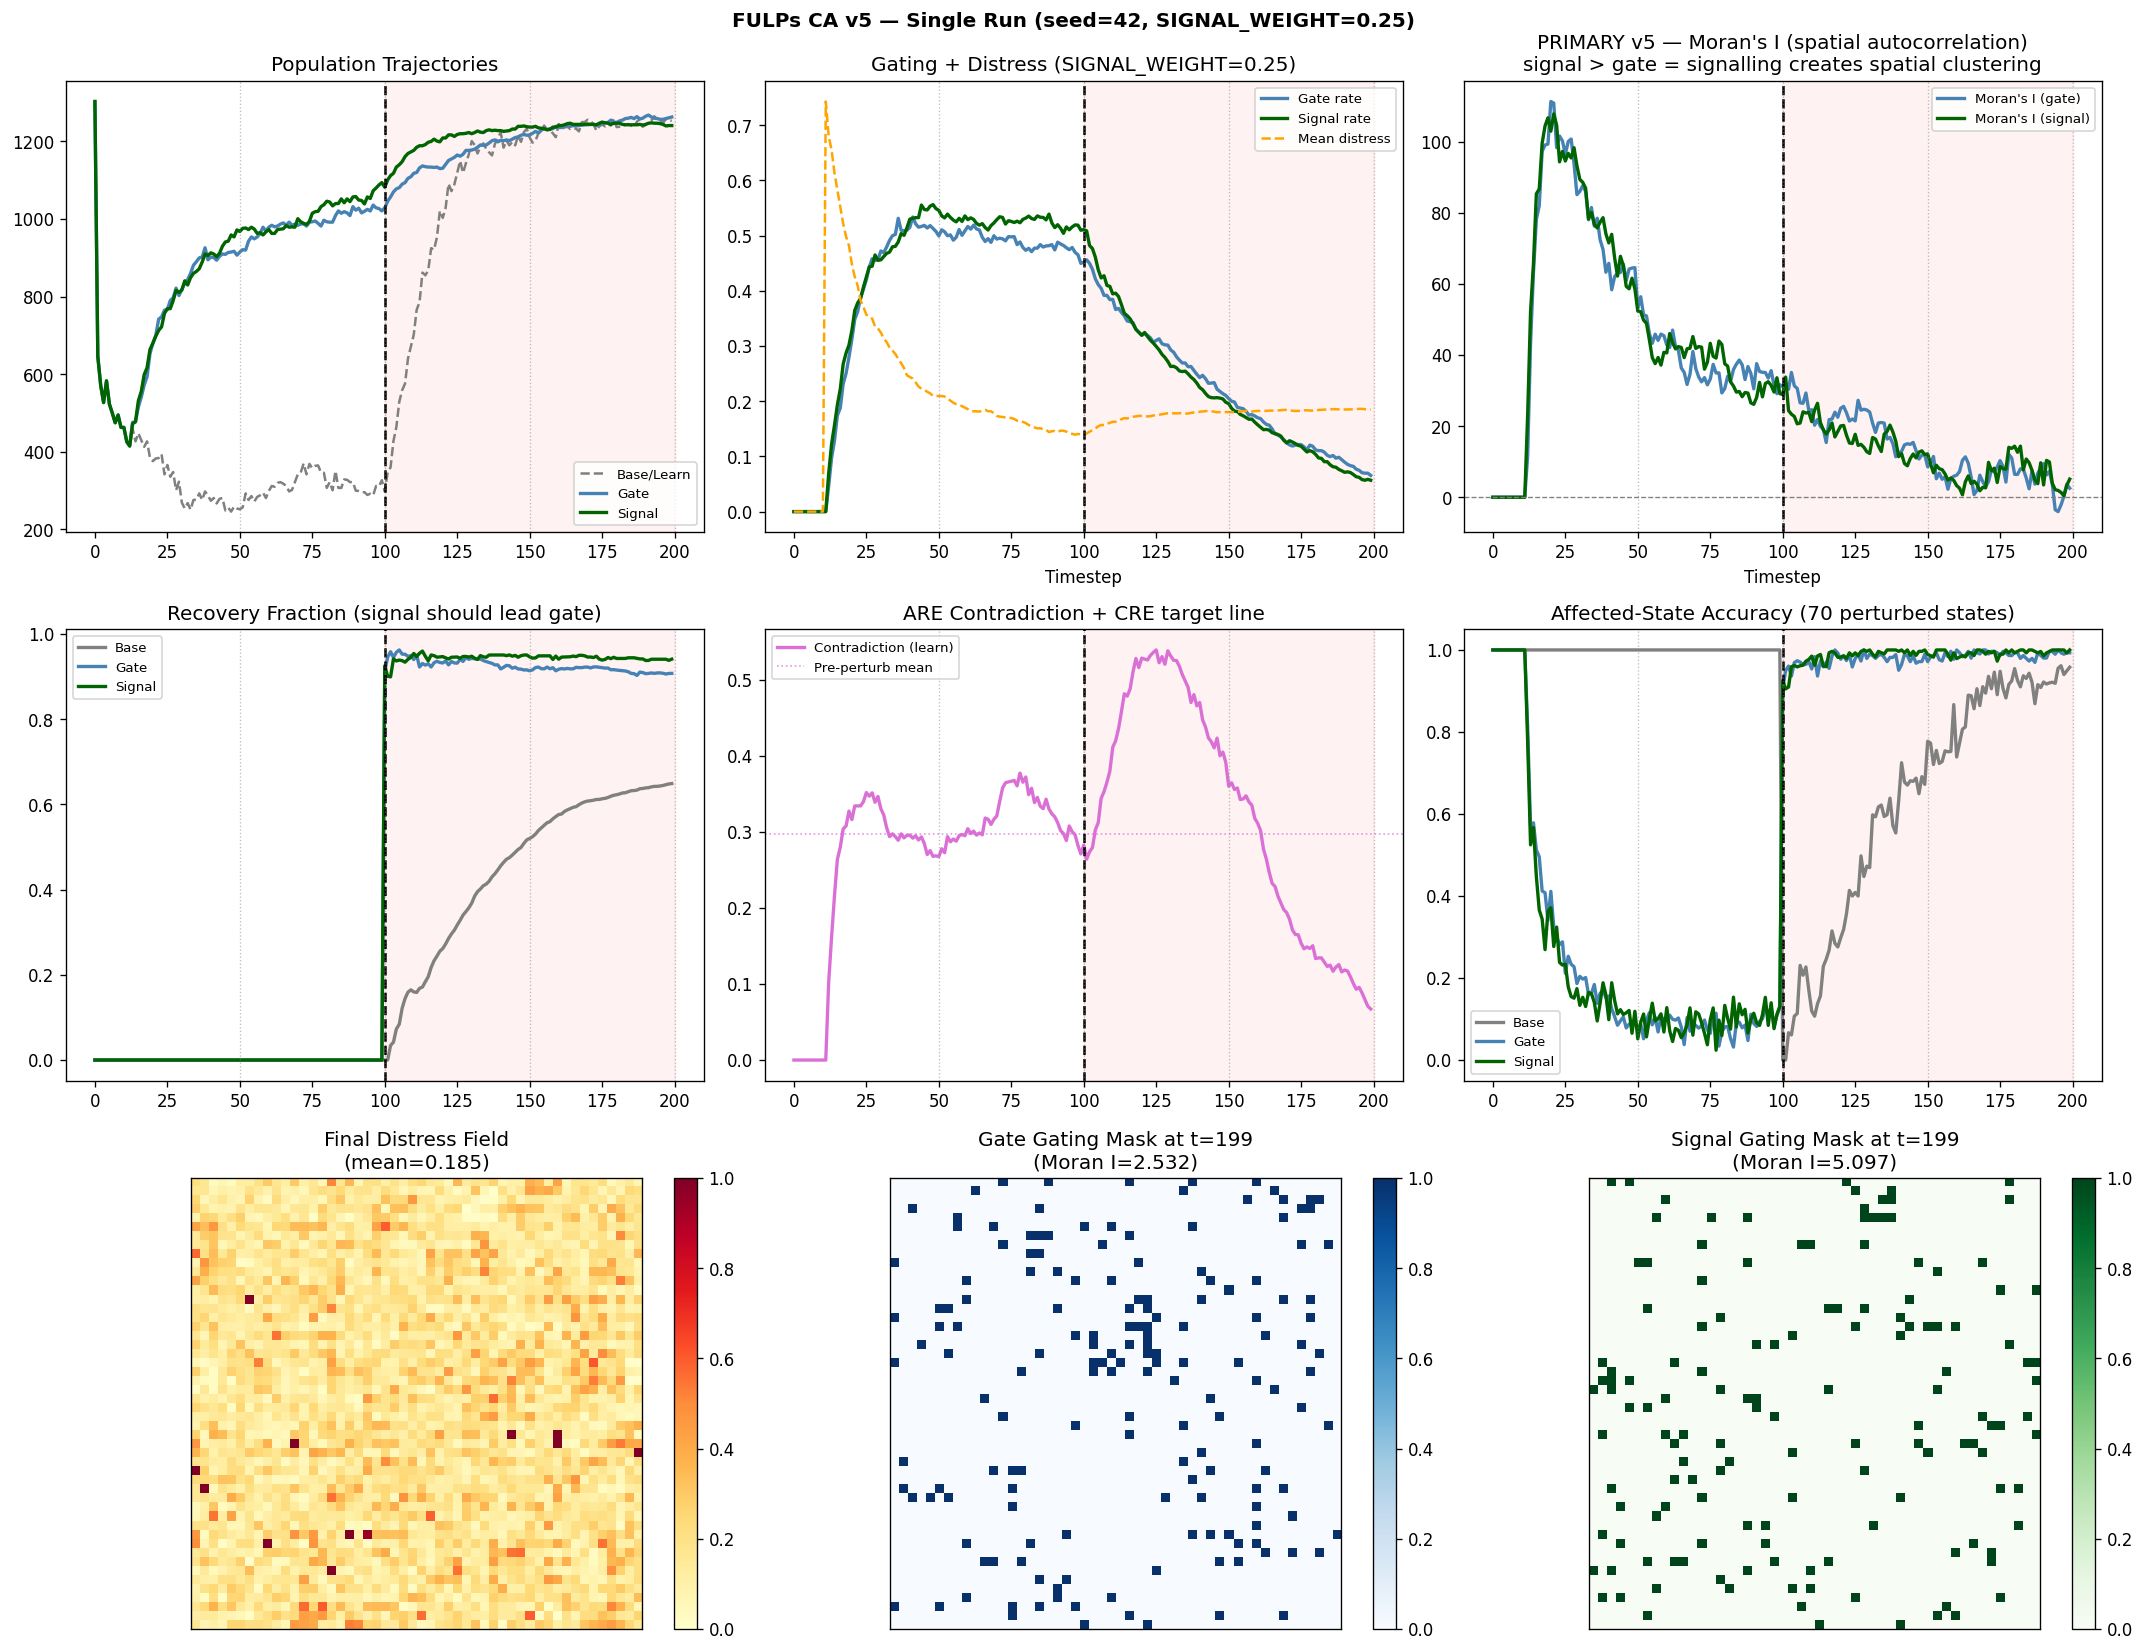

Saved: /content/fulps_ca_v5_single_run.png


In [12]:
# ── Cell 12: Single-Run Dashboard ────────────────────────────────────────────
fig=plt.figure(figsize=(18,14))
fig.suptitle(f'FULPs CA v5 — Single Run (seed=42, SIGNAL_WEIGHT={SIGNAL_WEIGHT})',
             fontsize=12,fontweight='bold')
T=list(range(N_TIMESTEPS))
def vl(ax):
    ax.axvspan(T_PERTURB,N_TIMESTEPS,alpha=0.05,color='red')
    ax.axvline(T_PERTURB,color='black',linestyle='--',lw=1.5)
    for w in [PRE_WIN_START,PRE_WIN_END,POST_WIN_START,POST_WIN_END]:
        ax.axvline(w,color='gray',linestyle=':',lw=0.8,alpha=0.5)

# Row 1: Population, Gating rates, Moran's I
ax=fig.add_subplot(3,3,1)
ax.plot(T,sh['pop_std'],color='gray',lw=1.5,linestyle='--',label='Base/Learn')
ax.plot(T,sh['pop_gate'],color='steelblue',lw=2,label='Gate')
ax.plot(T,sh['pop_sig'],color='darkgreen',lw=2,label='Signal')
vl(ax); ax.set_title('Population Trajectories'); ax.legend(fontsize=8)

ax=fig.add_subplot(3,3,2)
ax.plot(T,sh['gate_rate'],color='steelblue',lw=2,label='Gate rate')
ax.plot(T,sh['sig_rate'],color='darkgreen',lw=2,label='Signal rate')
ax.plot(T,sh['distress_mean'],color='orange',lw=1.5,linestyle='--',label='Mean distress')
vl(ax); ax.set_title(f'Gating + Distress (SIGNAL_WEIGHT={SIGNAL_WEIGHT})')
ax.set_xlabel('Timestep'); ax.legend(fontsize=8)

ax=fig.add_subplot(3,3,3)
ax.plot(T,sh['morans_gate'],color='steelblue',lw=2,label="Moran's I (gate)")
ax.plot(T,sh['morans_sig'],color='darkgreen',lw=2,label="Moran's I (signal)")
ax.axhline(0,color='gray',linestyle='--',lw=0.8)
vl(ax); ax.set_title("PRIMARY v5 — Moran's I (spatial autocorrelation)\n"
                     "signal > gate = signalling creates spatial clustering")
ax.set_xlabel('Timestep'); ax.legend(fontsize=8)

# Row 2: Recovery, Contradiction, Distress heatmap
ax=fig.add_subplot(3,3,4)
for key,col,lbl in [('rec_base','gray','Base'),('rec_gate','steelblue','Gate'),('rec_sig','darkgreen','Signal')]:
    ax.plot(T,sh[key],color=col,lw=2,label=lbl)
vl(ax); ax.set_title('Recovery Fraction (signal should lead gate)'); ax.legend(fontsize=8)

ax=fig.add_subplot(3,3,5)
ax.plot(T,sh['contra_l'],color='orchid',lw=2,label='Contradiction (learn)')
ax.axhline(np.mean(sh['contra_l'][SPIKE_PRE_START:SPIKE_PRE_END]),
           color='orchid',linestyle=':',lw=1,alpha=0.7,label='Pre-perturb mean')
vl(ax); ax.set_title('ARE Contradiction + CRE target line'); ax.legend(fontsize=8)

ax=fig.add_subplot(3,3,6)
for key,col,lbl in [('aff_base','gray','Base'),('aff_gate','steelblue','Gate'),('aff_sig','darkgreen','Signal')]:
    vals=sh[key]; Tv=[t for t,v in enumerate(vals) if not np.isnan(v)]
    ax.plot(Tv,[vals[t] for t in Tv],color=col,lw=2,label=lbl)
vl(ax); ax.set_title('Affected-State Accuracy (70 perturbed states)'); ax.legend(fontsize=8)

# Row 3: Heatmaps
ax=fig.add_subplot(3,3,7)
im=ax.imshow(sf['distress_final'],cmap='YlOrRd',vmin=0,vmax=1)
ax.set_title(f'Final Distress Field\n(mean={sf["distress_final"].mean():.3f})')
plt.colorbar(im,ax=ax,fraction=0.046); ax.set_xticks([]); ax.set_yticks([])

ax=fig.add_subplot(3,3,8)
im=ax.imshow(sf['gating_mask_final'].astype(float),cmap='Blues',vmin=0,vmax=1)
ax.set_title(f'Gate Gating Mask at t=199\n(Moran I={compute_morans_i(sf["gating_mask_final"]):.3f})')
plt.colorbar(im,ax=ax,fraction=0.046); ax.set_xticks([]); ax.set_yticks([])

ax=fig.add_subplot(3,3,9)
im=ax.imshow(sf['sig_mask_final'].astype(float),cmap='Greens',vmin=0,vmax=1)
ax.set_title(f'Signal Gating Mask at t=199\n(Moran I={compute_morans_i(sf["sig_mask_final"]):.3f})')
plt.colorbar(im,ax=ax,fraction=0.046); ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
p=os.path.join(OUT_DIR,'fulps_ca_v5_single_run.png')
plt.savefig(p,dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved: {p}')

In [13]:
# ── Cell 13: Multi-Run Study (50 runs) ───────────────────────────────────────
# Confirm single-run Layer 3 and 4 checks pass before running.
# If SIGNAL_WEIGHT needed tuning after Cell 11, update it in Cell 2 and re-run Cells 2-11.
print('='*60); print(f'STARTING 50-RUN STUDY (v5 — SIGNAL_WEIGHT={SIGNAL_WEIGHT})')
print('='*60); print(f'Seeds: {BASE_SEED}-{BASE_SEED+N_RUNS-1}\n')

MK=['base_final_tacc','learn_final_tacc','gate_final_tacc','sig_final_tacc',
    'gate_final_perstate','sig_final_perstate',
    'cv_base_pre','cv_gate_pre','cv_sig_pre',
    'cv_base_post','cv_gate_post','cv_sig_post',
    'base_recovery_t','gate_recovery_t','sig_recovery_t',
    'base_recovery_frac','gate_recovery_frac','sig_recovery_frac',
    'mi_gate_pre','mi_sig_pre','mi_gate_post','mi_sig_post',
    'cre_base','cre_gate','cre_sig',
    'gate_mean_overall','sig_mean_overall','distress_mean_overall',
    'contra_spike','gate_spike','sig_spike',
    'grid_div_gate','grid_div_sig',
    'stable_std','stable_gate','stable_sig']

all_res={k:[] for k in MK}; all_rows=[]

for ri in range(N_RUNS):
    seed=BASE_SEED+ri
    print(f'Run {ri+1:2d}/{N_RUNS}  (seed={seed})',end=' ... ')
    _,res,_=run_simulation(seed,void_model,IDF,is_single_run=False,verbose=False)
    for k in MK: all_res[k].append(res.get(k,np.nan))
    row={'run':ri+1,'seed':seed}; row.update(res); all_rows.append(row)
    if (ri+1)%BATCH_SIZE==0:
        bn=(ri+1)//BATCH_SIZE
        pd.DataFrame(all_rows[-BATCH_SIZE:]).to_csv(
            os.path.join(OUT_DIR,f'results_v5_batch_{bn}.csv'),index=False)
        mi_diff=np.nanmean(all_res['mi_sig_post'][-BATCH_SIZE:])-np.nanmean(all_res['mi_gate_post'][-BATCH_SIZE:])
        rt_diff=np.nanmean(all_res['gate_recovery_t'][-BATCH_SIZE:])-np.nanmean(all_res['sig_recovery_t'][-BATCH_SIZE:])
        print(f'\n  Batch {bn} saved.  Mi_diff={mi_diff:+.4f}  RecT_diff={rt_diff:+.2f}')
    else:
        print(f'Mi_sig={res.get("mi_sig_post",np.nan):.4f}  rec_sig={res.get("sig_recovery_t",np.nan):.1f}')

full_df=pd.DataFrame(all_rows)
fp=os.path.join(OUT_DIR,'results_50runs_ca_v5.csv')
full_df.to_csv(fp,index=False)
print(f'\nFull CSV -> {fp}')

STARTING 50-RUN STUDY (v5 — SIGNAL_WEIGHT=0.25)
Seeds: 42-91

Run  1/50  (seed=42) ... Mi_sig=6.6015  rec_sig=122.5
Run  2/50  (seed=43) ... Mi_sig=9.1971  rec_sig=125.7
Run  3/50  (seed=44) ... Mi_sig=7.5848  rec_sig=122.2
Run  4/50  (seed=45) ... Mi_sig=5.7975  rec_sig=121.4
Run  5/50  (seed=46) ... 
  Batch 1 saved.  Mi_diff=+2.9264  RecT_diff=+4.38
Run  6/50  (seed=47) ... Mi_sig=4.2878  rec_sig=127.0
Run  7/50  (seed=48) ... Mi_sig=5.3803  rec_sig=126.9
Run  8/50  (seed=49) ... Mi_sig=3.7592  rec_sig=124.2
Run  9/50  (seed=50) ... Mi_sig=10.6420  rec_sig=130.7
Run 10/50  (seed=51) ... 
  Batch 2 saved.  Mi_diff=+0.3751  RecT_diff=+0.55
Run 11/50  (seed=52) ... Mi_sig=4.5470  rec_sig=125.9
Run 12/50  (seed=53) ... Mi_sig=5.6527  rec_sig=128.8
Run 13/50  (seed=54) ... Mi_sig=3.1880  rec_sig=125.0
Run 14/50  (seed=55) ... Mi_sig=8.1156  rec_sig=128.6
Run 15/50  (seed=56) ... 
  Batch 3 saved.  Mi_diff=-2.9204  RecT_diff=+2.29
Run 16/50  (seed=57) ... Mi_sig=2.1221  rec_sig=120.2
Run 

In [14]:
# ── Cell 14: Statistical Summary ─────────────────────────────────────────────
print('='*60); print('50-RUN STATISTICAL SUMMARY — FULPs CA v5'); print('='*60)

def sa(k): return np.array([v for v in all_res[k] if not np.isnan(v)])
def sm(k): return np.nanmean(all_res[k])
def sc(k): return 1.96*np.nanstd(all_res[k])/np.sqrt(N_RUNS)
def cd(a,b): p=np.sqrt((a.std()**2+b.std()**2)/2); return (a.mean()-b.mean())/p if p>1e-9 else np.nan

print(f"\n  {'Metric':<32} {'Mean':>7} {'SD':>7} {'95%CI':>9}")
print('  '+'-'*58)
for k in MK:
    m=sm(k); s=np.nanstd(all_res[k]); ci=sc(k)
    if not np.isnan(m): print(f'  {k:<32} {m:>7.4f} {s:>7.4f}  +-{ci:>6.4f}')

print('\n'+'='*60); print('PRIMARY HYPOTHESIS TESTS'); print('='*60)

# P1: Signal Moran's I > Gate Moran's I (spatial coordination)
mi_g=sa('mi_gate_post'); mi_s=sa('mi_sig_post')
if len(mi_g)>2:
    t,p=stats.ttest_rel(mi_s,mi_g); d=cd(mi_s,mi_g)
    wins=(mi_s>mi_g).sum()
    print(f'\n  P1 [PRIMARY] Moran\'s I: signal > gate post-perturb (spatial clustering)')
    print(f'    sig={mi_s.mean():.4f}  gate={mi_g.mean():.4f}  t={t:.3f}  p={p:.4f}  d={d:.3f}')
    print(f'    Signal more clustered: {wins}/{len(mi_s)} runs')
    print(f'    -> {"SUPPORTED" if p<0.05 and mi_s.mean()>mi_g.mean() else "NOT SUPPORTED"}')

# P2: Signal CRE < Gate CRE (faster collective return)
cre_g=sa('cre_gate'); cre_s=sa('cre_sig')
if len(cre_g)>2:
    t2,p2=stats.ttest_rel(cre_s,cre_g); d2=cd(cre_s,cre_g)
    wins2=(cre_s<cre_g).sum()
    print(f'\n  P2 Collective Return to Equilibrium: signal < gate')
    print(f'    sig={cre_s.mean():.1f}  gate={cre_g.mean():.1f}  base={sa("cre_base").mean():.1f}')
    print(f'    t={t2:.3f}  p={p2:.4f}  d={d2:.3f}  signal faster: {wins2}/{len(cre_s)} runs')
    print(f'    -> {"SUPPORTED" if p2<0.05 and cre_s.mean()<cre_g.mean() else "NOT SUPPORTED"}')

# P3: Signal CV_post < Gate CV_post
cv_g=sa('cv_gate_post'); cv_s=sa('cv_sig_post'); cv_b=sa('cv_base_post')
if len(cv_g)>2:
    t3,p3=stats.ttest_rel(cv_s,cv_g); d3=cd(cv_s,cv_g)
    print(f'\n  P3 CV post-perturb: signal < gate (more stable)')
    print(f'    sig={cv_s.mean():.4f}  gate={cv_g.mean():.4f}  base={cv_b.mean():.4f}')
    print(f'    t={t3:.3f}  p={p3:.4f}  d={d3:.3f}')
    print(f'    -> {"SUPPORTED" if p3<0.05 and cv_s.mean()<cv_g.mean() else "NOT SUPPORTED"}')

# P4: Signal recovery < gate recovery (faster individual recovery)
rt_g=sa('gate_recovery_t'); rt_s=sa('sig_recovery_t'); rt_b=sa('base_recovery_t')
if len(rt_g)>2:
    t4,p4=stats.ttest_rel(rt_s,rt_g); d4=cd(rt_s,rt_g)
    wins4=(rt_s<rt_g).sum()
    print(f'\n  P4 Recovery timestep: signal < gate')
    print(f'    sig={rt_s.mean():.2f}  gate={rt_g.mean():.2f}  base={rt_b.mean():.2f}')
    print(f'    t={t4:.3f}  p={p4:.4f}  d={d4:.3f}  faster: {wins4}/{len(rt_s)} runs')
    print(f'    -> {"SUPPORTED" if p4<0.05 and rt_s.mean()<rt_g.mean() else "NOT SUPPORTED"}')

# Breakthrough verdict
print('\n'+'='*60); print('BREAKTHROUGH ASSESSMENT'); print('='*60)
b1 = len(mi_g)>2 and mi_s.mean()>mi_g.mean()
b2 = len(cre_g)>2 and cre_s.mean()<cre_g.mean()
b3 = len(cv_g)>2 and cv_s.mean()<cv_g.mean()
b4 = len(rt_g)>2 and rt_s.mean()<rt_g.mean()
for sig,label in [
    (b1, 'Moran\'s I(signal) > Moran\'s I(gate)  — signalling creates spatial clustering'),
    (b2, 'CRE(signal) < CRE(gate)               — faster collective return to equilibrium'),
    (b3, 'CV_post(signal) < CV_post(gate)        — signalling increases population stability'),
    (b4, 'Recovery(signal) < Recovery(gate)      — individual recovery also improves'),
]:
    print(f'  [{"PRESENT" if sig else "ABSENT "}]  {label}')
n=sum([b1,b2,b3,b4])
print(f'\n  Breakthrough indicators present: {n}/4')
if n==4:
    print()
    print('  *** BREAKTHROUGH DEMONSTRATED ***')
    print('  Locally communicated epistemic distress creates emergent spatial coordination')
    print('  in a deterministic CA — a qualitatively new adaptive property arising from')
    print('  FULPs FULP 6 (Environmental Interaction).')
    print('  No centralised control. No global design. Pure local-to-global emergence.')
elif n>=2:
    print('  PARTIAL BREAKTHROUGH — adjust SIGNAL_WEIGHT and re-run.')
else:
    print('  NOT YET — check Layer 3 (signalling mechanism) and SIGNAL_WEIGHT.')

50-RUN STATISTICAL SUMMARY — FULPs CA v5

  Metric                              Mean      SD     95%CI
  ----------------------------------------------------------
  base_final_tacc                   0.5997  0.0007  +-0.0002
  learn_final_tacc                  0.6187  0.0026  +-0.0007
  gate_final_tacc                   0.6011  0.0004  +-0.0001
  sig_final_tacc                    0.6007  0.0004  +-0.0001
  gate_final_perstate               0.7350  0.0034  +-0.0009
  sig_final_perstate                0.7305  0.0033  +-0.0009
  cv_base_pre                       0.1326  0.0562  +-0.0156
  cv_gate_pre                       0.0231  0.0090  +-0.0025
  cv_sig_pre                        0.0209  0.0081  +-0.0022
  cv_base_post                      0.0158  0.0091  +-0.0025
  cv_gate_post                      0.0047  0.0023  +-0.0006
  cv_sig_post                       0.0048  0.0028  +-0.0008
  base_recovery_t                  162.6013  3.3250  +-0.9216
  gate_recovery_t                  126.696

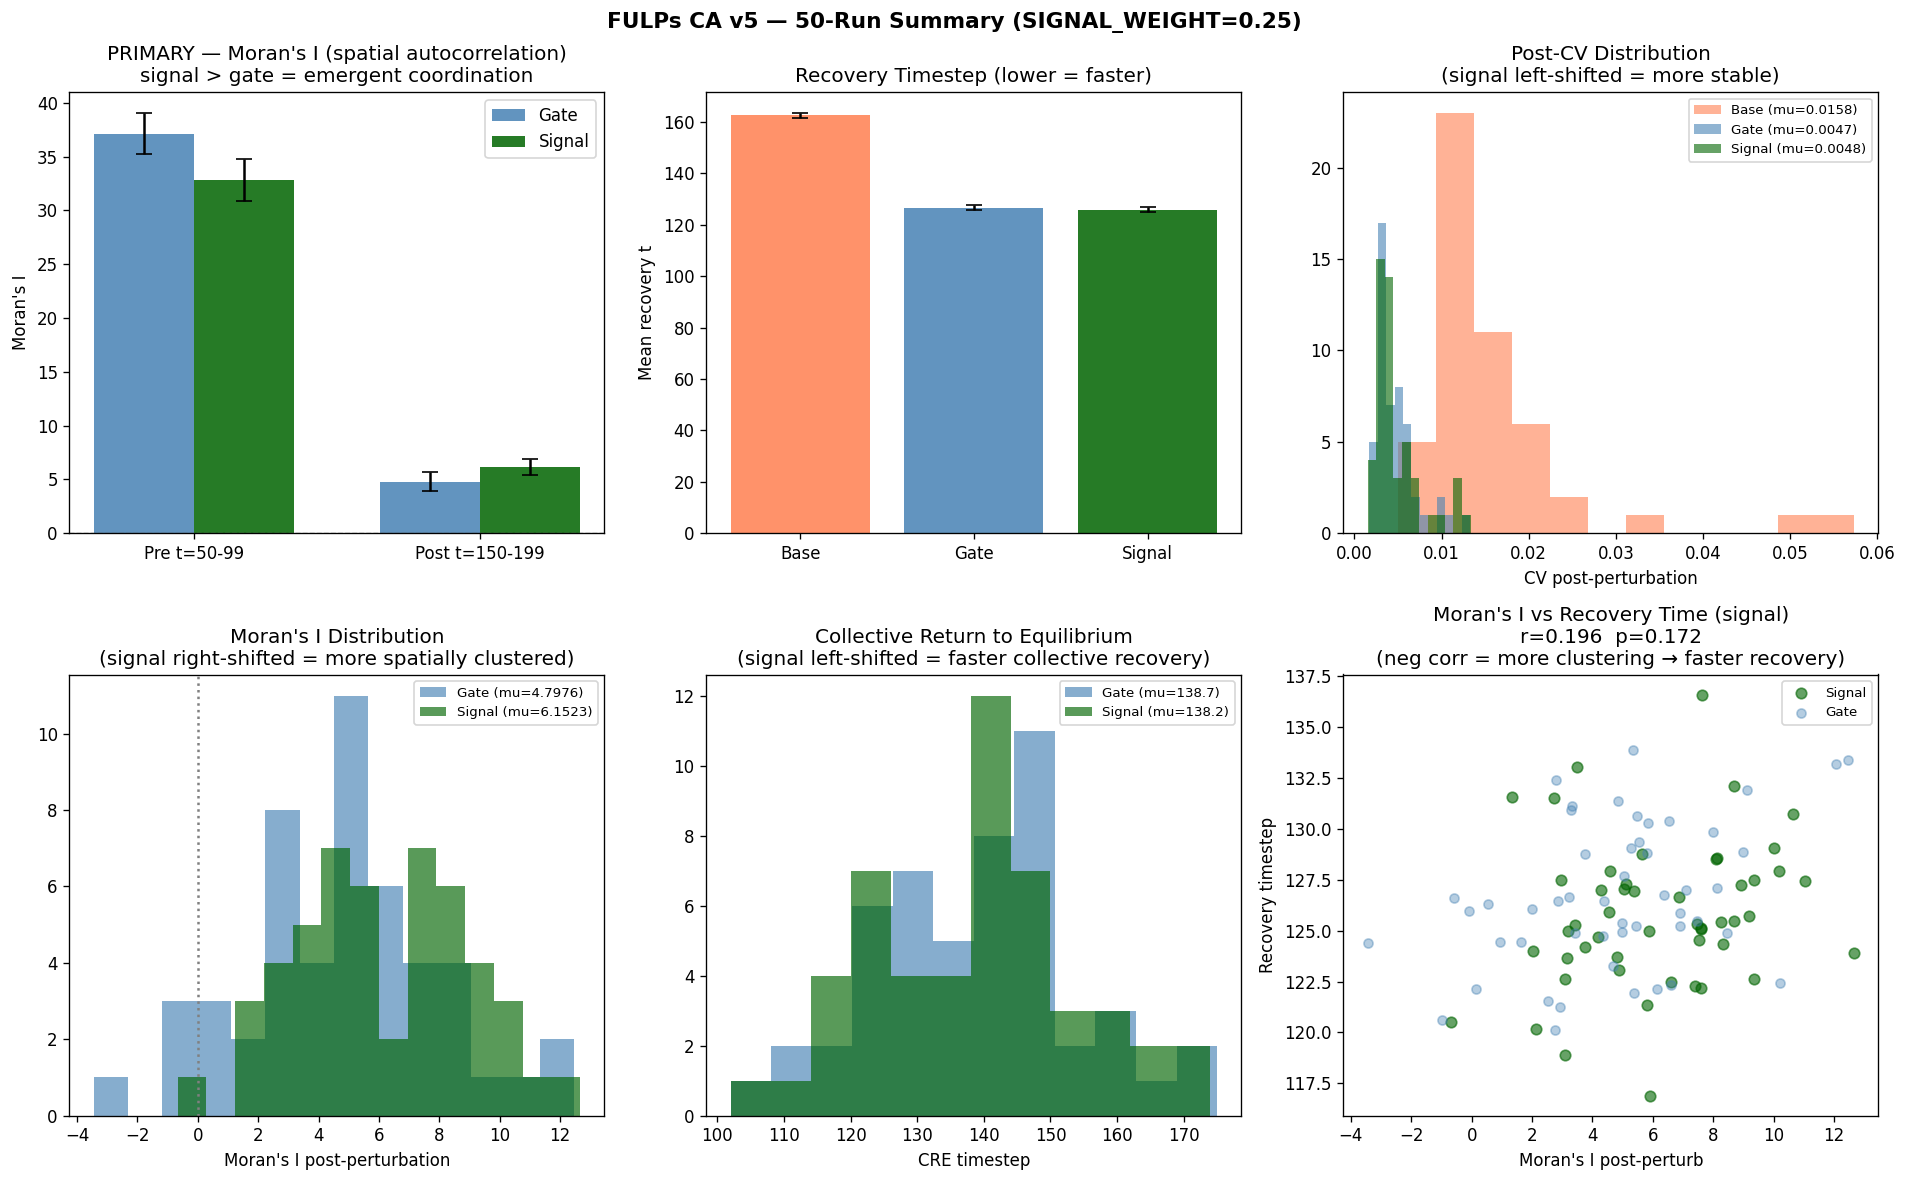

Saved: /content/fulps_ca_v5_multirun.png  |  Full CSV: /content/results_50runs_ca_v5.csv


In [15]:
# ── Cell 15: Multi-Run Visualisation ─────────────────────────────────────────
fig,axes=plt.subplots(2,3,figsize=(16,10))
fig.suptitle(f"FULPs CA v5 — 50-Run Summary (SIGNAL_WEIGHT={SIGNAL_WEIGHT})",
             fontsize=13,fontweight='bold')

def sa(k): return np.array([v for v in all_res[k] if not np.isnan(v)])
def sm(k): return np.nanmean(all_res[k])
def sc(k): return 1.96*np.nanstd(all_res[k])/np.sqrt(N_RUNS)

# PRIMARY: Moran's I comparison
ax=axes[0,0]
cats=['Pre t=50-99','Post t=150-199']
mi_g_v=[sm('mi_gate_pre'),sm('mi_gate_post')]; mi_s_v=[sm('mi_sig_pre'),sm('mi_sig_post')]
ci_g=[sc('mi_gate_pre'),sc('mi_gate_post')]; ci_s=[sc('mi_sig_pre'),sc('mi_sig_post')]
x,w=np.arange(2),0.35
ax.bar(x-w/2,mi_g_v,w,yerr=ci_g,capsize=5,color='steelblue',alpha=0.85,label='Gate')
ax.bar(x+w/2,mi_s_v,w,yerr=ci_s,capsize=5,color='darkgreen',alpha=0.85,label='Signal')
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title("PRIMARY — Moran's I (spatial autocorrelation)\nsignal > gate = emergent coordination")
ax.set_ylabel("Moran's I"); ax.legend(); ax.axhline(0,color='gray',linestyle='--',lw=0.8)

# Recovery timestep
ax=axes[0,1]
conds=['Base','Gate','Signal']
rt_m=[sm('base_recovery_t'),sm('gate_recovery_t'),sm('sig_recovery_t')]
rt_ci=[sc('base_recovery_t'),sc('gate_recovery_t'),sc('sig_recovery_t')]
ax.bar(range(3),rt_m,yerr=rt_ci,capsize=5,color=['coral','steelblue','darkgreen'],alpha=0.85)
ax.set_xticks(range(3)); ax.set_xticklabels(conds)
ax.set_title('Recovery Timestep (lower = faster)'); ax.set_ylabel('Mean recovery t')

# CV post
ax=axes[0,2]
cv_b=sa('cv_base_post'); cv_g=sa('cv_gate_post'); cv_s=sa('cv_sig_post')
for v,col,lbl in [(cv_b,'coral','Base'),(cv_g,'steelblue','Gate'),(cv_s,'darkgreen','Signal')]:
    if len(v)>0: ax.hist(v,bins=12,alpha=0.6,color=col,label=f'{lbl} (mu={v.mean():.4f})')
ax.set_xlabel('CV post-perturbation')
ax.set_title('Post-CV Distribution\n(signal left-shifted = more stable)'); ax.legend(fontsize=8)

# Moran's I distributions
ax=axes[1,0]
mi_g_d=sa('mi_gate_post'); mi_s_d=sa('mi_sig_post')
if len(mi_g_d)>0: ax.hist(mi_g_d,bins=14,alpha=0.65,color='steelblue',
                            label=f"Gate (mu={mi_g_d.mean():.4f})")
if len(mi_s_d)>0: ax.hist(mi_s_d,bins=14,alpha=0.65,color='darkgreen',
                            label=f"Signal (mu={mi_s_d.mean():.4f})")
ax.axvline(0,color='gray',linestyle=':',lw=1.5)
ax.set_xlabel("Moran's I post-perturbation")
ax.set_title("Moran's I Distribution\n(signal right-shifted = more spatially clustered)")
ax.legend(fontsize=8)

# CRE distribution
ax=axes[1,1]
cre_g=sa('cre_gate'); cre_s=sa('cre_sig')
if len(cre_g)>0: ax.hist(cre_g,bins=12,alpha=0.65,color='steelblue',
                          label=f'Gate (mu={cre_g.mean():.1f})')
if len(cre_s)>0: ax.hist(cre_s,bins=12,alpha=0.65,color='darkgreen',
                          label=f'Signal (mu={cre_s.mean():.1f})')
ax.set_xlabel('CRE timestep')
ax.set_title('Collective Return to Equilibrium\n(signal left-shifted = faster collective recovery)')
ax.legend(fontsize=8)

# Moran's I vs recovery scatter
ax=axes[1,2]
mi_sv=sa('mi_sig_post'); rt_sv=sa('sig_recovery_t')
mn=min(len(mi_sv),len(rt_sv))
if mn>2:
    ax.scatter(mi_sv[:mn],rt_sv[:mn],color='darkgreen',alpha=0.6,s=40,label='Signal')
    r,pr=stats.pearsonr(mi_sv[:mn],rt_sv[:mn])
    ax.set_title(f"Moran's I vs Recovery Time (signal)\nr={r:.3f}  p={pr:.3f}\n"
                 '(neg corr = more clustering → faster recovery)')
    mi_gv=sa('mi_gate_post'); rt_gv=sa('gate_recovery_t'); mn2=min(len(mi_gv),len(rt_gv))
    if mn2>2: ax.scatter(mi_gv[:mn2],rt_gv[:mn2],color='steelblue',alpha=0.4,s=30,label='Gate')
ax.set_xlabel("Moran's I post-perturb"); ax.set_ylabel('Recovery timestep')
ax.legend(fontsize=8)

plt.tight_layout()
mp=os.path.join(OUT_DIR,'fulps_ca_v5_multirun.png')
plt.savefig(mp,dpi=150,bbox_inches='tight'); plt.show()
print(f'Saved: {mp}  |  Full CSV: {fp}')